# Análise da Gold materializada

Este notebook **consome** a camada Gold já pronta — as cinco tabelas que `src/03_gold/metricas_gold.py` grava em `data/gold/`. Enquanto o [`laboratorio_gold.ipynb`](laboratorio_gold.ipynb) é o rascunho que *desenha* a Gold a partir da Silver, aqui a régua já está aplicada: a ideia é ler o produto final, conferir se ele tem a cara esperada e sustentar as análises que só as tabelas prontas permitem: a **Parte 1** confere o produto, a **Parte 2** põe as tabelas para trabalhar.

## As cinco tabelas

| Tabela | Grão | Responde |
|---|---|---|
| `indicador_municipio` | ano × município | quantas crianças estão alfabetizadas, e onde |
| `meta_vs_resultado` | ano × nível × recorte | quem está longe da meta pactuada |
| `evolucao_temporal` | ano × recorte × rede | como o indicador se move no tempo |
| `perfil_escola` | ano × escola | quais escolas superam (ou ficam abaixo) do próprio contexto |
| `distribuicao_proficiencia` | ano × recorte × rede | onde as crianças estão na escala |



> Pré-requisito: rodar `python src/03_gold/metricas_gold.py` antes, para materializar `data/gold/`.

In [ ]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

GOLD = Path("../data/gold")
pd.set_option("display.max_columns", 40)

# paleta validada (a mesma do laboratório, para os dois notebooks falarem a mesma língua)
AZUL, AQUA, AMARELO = "#2a78d6", "#1baf7a", "#eda100"
VERMELHO, LARANJA, VERDE = "#d03b3b", "#fab219", "#0ca30c"
TINTA, TINTA_2, MUDO = "#0b0b0b", "#52514e", "#898781"
GRADE, FUNDO, EIXO = "#e1e0d9", "#fcfcfb", "#c3c2b7"

mpl.rcParams.update({
    "figure.figsize": (9, 4.4), "figure.facecolor": FUNDO, "figure.dpi": 110,
    "axes.facecolor": FUNDO, "axes.edgecolor": EIXO,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.axisbelow": True, "grid.color": GRADE, "grid.linewidth": 0.8,
    "xtick.color": MUDO, "ytick.color": MUDO, "text.color": TINTA,
    "font.size": 10, "legend.frameon": False,
})


def titulos(ax, titulo, subtitulo):
    """Título + a frase que diz o que o leitor tem que enxergar no gráfico."""
    ax.set_title(titulo, pad=26)
    ax.text(0, 1.04, subtitulo, transform=ax.transAxes,
            color=TINTA_2, fontsize=9.5, va="bottom")


print("configurado")

configurado


---

# Parte 1 — conferindo o produto

## Carregando as cinco tabelas

Cada tabela é um `data.parquet` dentro da sua pasta. Carrego as cinco e confiro o grão (linhas × colunas) de cada uma.

In [ ]:
ind_mun = pd.read_parquet(GOLD / "indicador_municipio" / "data.parquet")
meta_res = pd.read_parquet(GOLD / "meta_vs_resultado" / "data.parquet")
evol = pd.read_parquet(GOLD / "evolucao_temporal" / "data.parquet")
perfil = pd.read_parquet(GOLD / "perfil_escola" / "data.parquet")
distrib = pd.read_parquet(GOLD / "distribuicao_proficiencia" / "data.parquet")

for nome, df in [("indicador_municipio", ind_mun), ("meta_vs_resultado", meta_res),
                 ("evolucao_temporal", evol), ("perfil_escola", perfil),
                 ("distribuicao_proficiencia", distrib)]:
    print(f"{nome:28s} {len(df):>7,} linhas × {df.shape[1]:>2} colunas")

indicador_municipio           10,391 linhas × 14 colunas
meta_vs_resultado             10,327 linhas × 12 colunas
evolucao_temporal             33,411 linhas × 13 colunas
perfil_escola                 79,264 linhas × 14 colunas
distribuicao_proficiencia     33,392 linhas × 19 colunas


### `indicador_municipio` — quantas crianças, e onde

O grão é ano × município. Além da `taxa_alfabetizacao`, ela traz o que o laboratório mostrou que faltava: a margem de erro (`ic95`), a participação (`taxa_participacao`) e o **volume absoluto** de crianças fora da alfabetização (`criancas_nao_alfabetizadas`) — a coluna que separa "pior taxa" de "mais crianças".

In [ ]:
top = (ind_mun[ind_mun["ano"] == 2024]
       .nlargest(10, "criancas_nao_alfabetizadas")
       [["sigla_uf", "id_municipio", "taxa_alfabetizacao", "ic95",
         "taxa_participacao", "criancas_nao_alfabetizadas"]])
print("2024 — os 10 municípios com mais crianças fora da alfabetização:")
top.round(1)

2024 — os 10 municípios com mais crianças fora da alfabetização:


,sigla_uf,id_municipio,taxa_alfabetizacao,ic95,taxa_participacao,criancas_nao_alfabetizadas
8670,SP,3550308,56.1,0.3,87.6,47281.0
8086,RJ,3304557,63.8,0.5,86.9,18080.0
4983,AM,1302603,51.4,0.6,75.8,14846.0
10390,DF,5300108,59.1,0.7,79.8,11313.0
8323,SP,3518800,49.2,0.9,85.4,7804.0
7008,BA,2927408,36.9,0.9,87.9,7677.0
9758,RS,4314902,27.5,1.1,71.8,7453.0
7154,MG,3106200,70.1,0.7,84.7,5650.0
9944,MS,5002704,51.6,1.0,89.2,5425.0
8846,PR,4106902,66.0,0.8,81.4,5403.0


### `meta_vs_resultado` — quem está longe da meta

A coluna `situacao_meta` é a resposta do Ato 3.2 do laboratório: ela tem um terceiro estado, `indistinguivel`, para os municípios em que o gap até a meta é menor que a própria margem de erro — onde dizer "atingiu" ou "não atingiu" é reportar ruído como fato.

In [ ]:
print("distribuição de situacao_meta (todos os níveis e recortes):")
print(meta_res["situacao_meta"].value_counts().to_string())
print()
print("indistinguivel = o gap até a meta é menor que a própria margem de erro (ic95)")

distribuição de situacao_meta (todos os níveis e recortes):
situacao_meta
sem_meta          5070
indistinguivel    2357
atingiu           1649
nao_atingiu       1251

indistinguivel = o gap até a meta é menor que a própria margem de erro (ic95)


### `evolucao_temporal` — o indicador no tempo

Mesmo conteúdo do indicador, mas empilhado por recorte geográfico (brasil / uf / município) e rede, para ler a série. No nível Brasil dá para conferir o número oficial.

In [ ]:
brasil = evol[evol["nivel"] == "brasil"][["ano", "rede", "taxa_alfabetizacao",
                                           "taxa_participacao"]]
print("Brasil, por ano e rede (a rede 'publica' de 2024 fecha em 59,2 — o número oficial):")
print(brasil.round(1).to_string(index=False))

Brasil, por ano e rede (a rede 'publica' de 2024 fecha em 59,2 — o número oficial):
 ano      rede  taxa_alfabetizacao  taxa_participacao
2023 municipal                57.2               86.2
2024 municipal                58.8               87.6
2023  estadual                60.1               84.8
2024  estadual                61.6               86.0
2023   publica                57.5               86.0
2024   publica                59.2               87.4
2023     total                57.5               86.0
2024     total                59.2               87.4


### `perfil_escola` — a escola que ninguém olhava

O grão que faltava. Para cada escola, o `residuo` mede o quanto ela se afasta do próprio município — controlando contexto socioeconômico, prefeitura e rede. O filtro de 20+ alunos evita o ruído de escola pequena (o mesmo "funil" do Ato 3.2).

In [ ]:
robustas = perfil[(perfil["ano"] == 2024) & (perfil["alunos_com_nota"] >= 20)]
print(f"escolas 2024 com 20+ alunos com nota: {len(robustas):,}")
print(f"  {int((robustas['residuo'] > 20).sum()):,} escolas 20pp ACIMA do próprio município")
print(f"  {int((robustas['residuo'] < -20).sum()):,} escolas 20pp ABAIXO")
print()
print("as 5 escolas que mais superam o próprio contexto:")
robustas.nlargest(5, "residuo")[["sigla_uf", "id_municipio", "id_escola",
                                 "taxa_alfabetizacao", "taxa_municipio", "residuo"]].round(1)

escolas 2024 com 20+ alunos com nota: 31,468
  2,083 escolas 20pp ACIMA do próprio município
  2,008 escolas 20pp ABAIXO

as 5 escolas que mais superam o próprio contexto:


,sigla_uf,id_municipio,id_escola,taxa_alfabetizacao,taxa_municipio,residuo
38520,PA,1500305,60001753,100.0,38.2,61.8
51885,BA,2925253,60015119,90.5,37.0,53.5
52822,BA,2927408,60016056,90.0,36.9,53.1
53819,BA,2925105,60017053,95.4,42.9,52.5
47863,PB,2513703,60011097,90.9,39.4,51.5


### `distribuicao_proficiencia` — onde as crianças estão na escala

Não só se passaram do corte: as 9 faixas oficiais do INEP (reconstruídas e validadas no Ato 4.1) mais as faixas de negócio. A `pct_quase_la` mede o contingente logo abaixo do corte — onde o esforço rende mais rápido.

In [ ]:
pub = distrib[(distrib["nivel"] == "brasil") & (distrib["rede"] == "publica")]
print("Brasil, rede pública — faixas de negócio por ano:")
print(pub[["ano", "pct_critico", "pct_atencao", "pct_alfabetizado",
           "pct_quase_la"]].round(1).to_string(index=False))
print()
print("pct_quase_la = crianças a até 10 pontos do corte; +7,8pp na taxa se cruzassem")

Brasil, rede pública — faixas de negócio por ano:
 ano  pct_critico  pct_atencao  pct_alfabetizado  pct_quase_la
2023         17.8         24.7              57.5           8.0
2024         16.7         24.1              59.2           7.8

pct_quase_la = crianças a até 10 pontos do corte; +7,8pp na taxa se cruzassem


---

# Parte 2 — o que a Gold responde

A Parte 1 conferiu o produto; agora as tabelas trabalham. Cada seção segue o ritmo do laboratório — **pergunta → código → o que o número quer dizer** — mas aqui nenhuma célula toca a Silver: tudo sai das cinco tabelas prontas.

## 2.1 — A evolução que dá para ler: o mapa por UF

O grão UF é onde a série 2023 → 2024 é legível de verdade: dezenas de milhares de alunos por estado, margem de erro na casa de ±0,3pp. A `evolucao_temporal` dá as duas pontas; o desenho natural é um *dumbbell* — cada UF é uma linha, do valor de 2023 ao de 2024.

(Três UFs — AC, DF e SP — só têm um dos anos publicado no grão UF, e ficam de fora do desenho.)

UFs com os dois anos publicados: 23
amplitude em 2024: 49.4pp — CE (85.3%) × BA (36.0%)
UFs que recuaram: 6 | maior avanço: MG (+12.3pp) | maior queda: RS (-18.7pp)


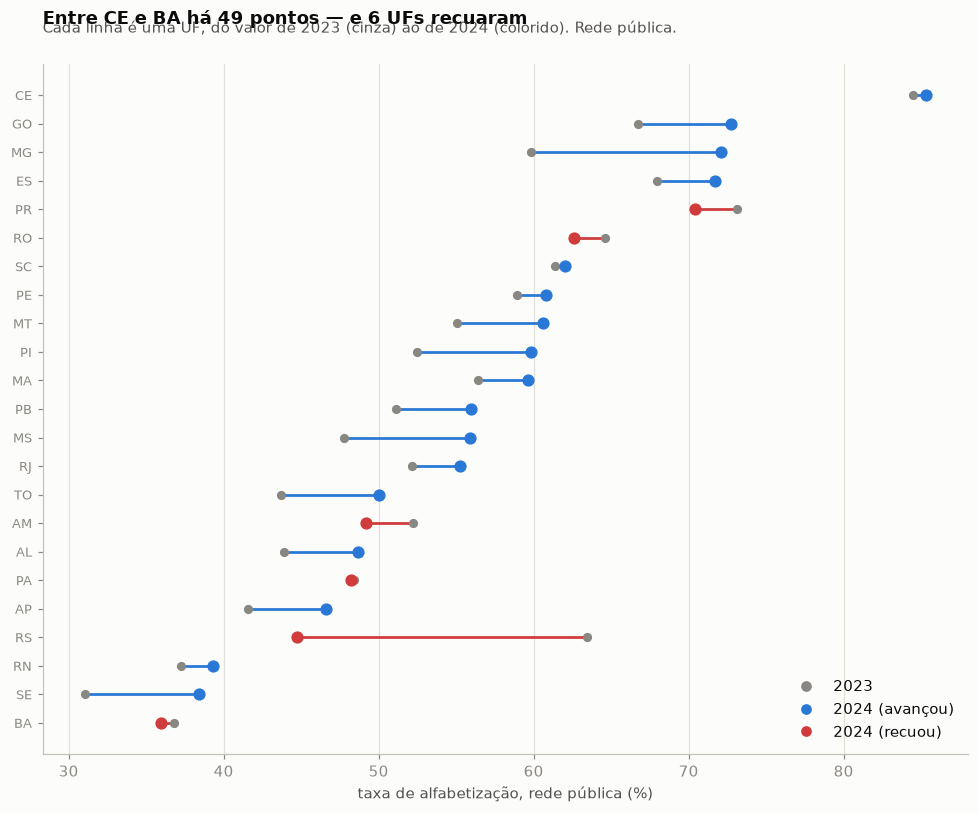

In [ ]:
from matplotlib.lines import Line2D

uf = evol[(evol["nivel"] == "uf") & (evol["rede"] == "publica")]
serie_uf = uf.pivot_table(index="sigla_uf", columns="ano",
                          values="taxa_alfabetizacao").dropna()
serie_uf["avanco"] = serie_uf[2024] - serie_uf[2023]
serie_uf = serie_uf.sort_values(2024)

print(f"UFs com os dois anos publicados: {len(serie_uf)}")
print(f"amplitude em 2024: {serie_uf[2024].max() - serie_uf[2024].min():.1f}pp — "
      f"{serie_uf[2024].idxmax()} ({serie_uf[2024].max():.1f}%) × "
      f"{serie_uf[2024].idxmin()} ({serie_uf[2024].min():.1f}%)")
print(f"UFs que recuaram: {int((serie_uf['avanco'] < 0).sum())} | "
      f"maior avanço: {serie_uf['avanco'].idxmax()} ({serie_uf['avanco'].max():+.1f}pp) | "
      f"maior queda: {serie_uf['avanco'].idxmin()} ({serie_uf['avanco'].min():+.1f}pp)")

fig, ax = plt.subplots(figsize=(9, 7.5))
for i, (sigla, linha) in enumerate(serie_uf.iterrows()):
    cor = VERMELHO if linha["avanco"] < 0 else AZUL
    ax.plot([linha[2023], linha[2024]], [i, i], color=cor, linewidth=1.8, zorder=2)
    ax.plot(linha[2023], i, "o", color=MUDO, markersize=5, zorder=3)
    ax.plot(linha[2024], i, "o", color=cor, markersize=7, zorder=3)

ax.set_yticks(range(len(serie_uf)), serie_uf.index, fontsize=8.5)
ax.set_xlabel("taxa de alfabetização, rede pública (%)")
ax.grid(axis="x")
ax.legend(handles=[
    Line2D([], [], marker="o", linestyle="none", color=MUDO, label="2023"),
    Line2D([], [], marker="o", linestyle="none", color=AZUL, label="2024 (avançou)"),
    Line2D([], [], marker="o", linestyle="none", color=VERMELHO, label="2024 (recuou)"),
], loc="lower right")
titulos(ax, "Entre CE e BA há 49 pontos — e 6 UFs recuaram",
        "Cada linha é uma UF, do valor de 2023 (cinza) ao de 2024 (colorido). Rede pública.")
plt.tight_layout()
plt.show()

O gráfico diz três coisas que o número Brasil (57,5% → 59,2%) esconde:

1. **A amplitude é de 49 pontos.** O CE (85,3%) e a BA (36,0%) estão mais longe um do outro do que o Brasil está de qualquer meta. Falar em "taxa nacional" mistura países diferentes.
2. **6 UFs recuaram** num ano em que o país subiu.
3. **O RS não recuou — despencou** (−18,7pp), e a queda é tão fora da curva que merece seção própria.

## 2.2 — O caso RS: quando o `ic95` confirma a exceção

Uma queda de 18,7 pontos em um ano é o tipo de número que, num município pequeno, seria ruído amostral — o funil do laboratório está cheio de quedas assim. A pergunta certa é: **o RS é funil ou é fato?** A Gold responde com as colunas que ela carrega para exatamente isso: `ic95`, `taxa_participacao` e `alunos_com_nota`.

In [ ]:
rs = evol[(evol["nivel"] == "uf") & (evol["rede"] == "publica")
          & (evol["sigla_uf"] == "RS")]
print("RS, rede pública:")
print(rs[["ano", "taxa_alfabetizacao", "ic95", "taxa_participacao",
          "alunos_com_nota"]].round(1).to_string(index=False))

queda = rs.set_index("ano")["taxa_alfabetizacao"]
ic = rs["ic95"].max()
print()
print(f"queda: {queda[2024] - queda[2023]:+.1f}pp — {abs(queda[2024] - queda[2023]) / ic:.0f}× a margem de erro")

RS, rede pública:
 ano  taxa_alfabetizacao  ic95  taxa_participacao  alunos_com_nota
2023                63.4   0.3               81.4            98660
2024                44.8   0.3               82.9            89562

queda: -18.7pp — 57× a margem de erro


Nenhuma das explicações baratas sobrevive: são ~90 mil alunos avaliados (ic95 de ±0,3pp — a queda é quase 60 vezes a margem), a participação até **subiu** (81,4% → 82,9%, então não é evasão da prova) e o recorte é o mesmo nos dois anos. A queda é real — e 2024 foi o ano da enchente que fechou escolas por meses no estado. A base não traz a causa, mas o calendário é eloquente.

O reflexo aparece no confronto com a meta:

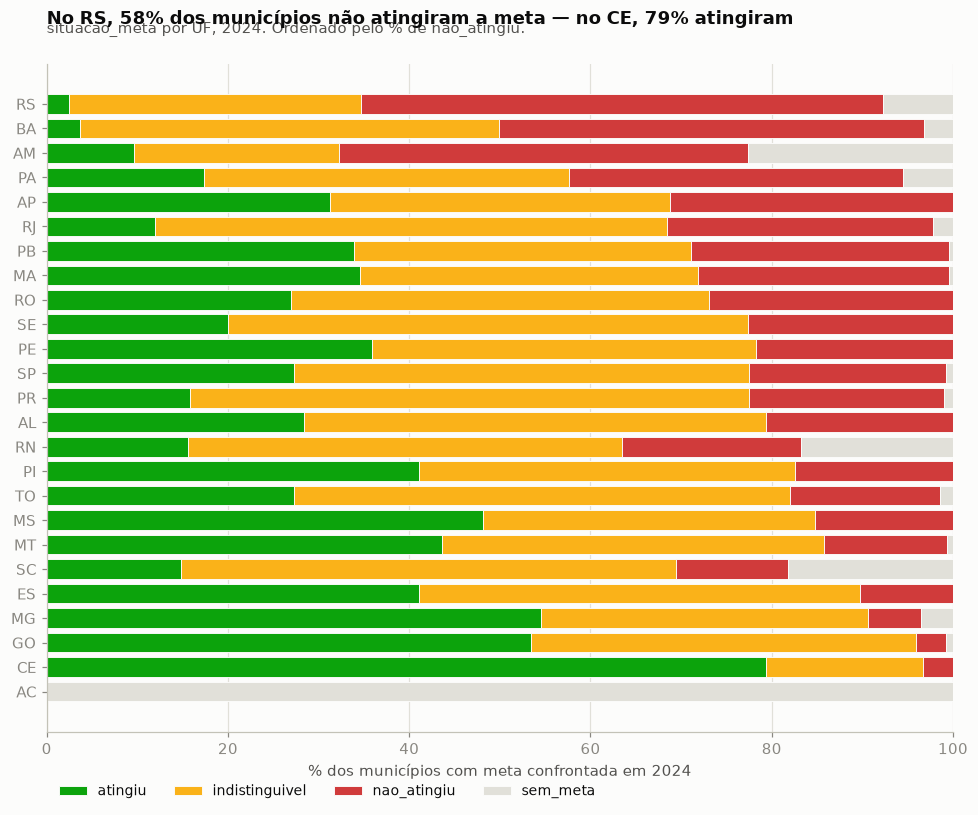

In [ ]:
mm24 = meta_res[(meta_res["nivel"] == "municipio") & (meta_res["ano"] == 2024)]
quadro = (mm24.groupby("sigla_uf")["situacao_meta"].value_counts(normalize=True)
          .unstack(fill_value=0) * 100)
ordem_cat = ["atingiu", "indistinguivel", "nao_atingiu", "sem_meta"]
quadro = quadro.reindex(columns=ordem_cat, fill_value=0).sort_values("nao_atingiu")
cores_cat = {"atingiu": VERDE, "indistinguivel": LARANJA,
             "nao_atingiu": VERMELHO, "sem_meta": GRADE}

fig, ax = plt.subplots(figsize=(9, 7.5))
esquerda = np.zeros(len(quadro))
for cat in ordem_cat:
    ax.barh(quadro.index, quadro[cat], left=esquerda, color=cores_cat[cat],
            edgecolor=FUNDO, linewidth=0.6, label=cat)
    esquerda += quadro[cat].values

ax.set_xlim(0, 100)
ax.set_xlabel("% dos municípios com meta confrontada em 2024")
ax.grid(axis="x")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.06), ncols=4, fontsize=9)
titulos(ax, "No RS, 58% dos municípios não atingiram a meta — no CE, 79% atingiram",
        "situacao_meta por UF, 2024. Ordenado pelo % de nao_atingiu.")
plt.tight_layout()
plt.show()

**58% dos municípios gaúchos não atingiram a meta de 2024** — a pior proporção do país, num estado que em 2023 estava acima da média nacional. No outro extremo, o CE: 79% atingiram.

Duas notas de leitura, ambas herança do laboratório: a fatia laranja (`indistinguivel`) marca os municípios em que o gap é menor que a margem de erro — cobrá-los seria cobrar ruído; e o AC aparece 100% `sem_meta` porque a fonte não publicou meta municipal para o estado — ausência documentada, não erro do pipeline.

## 2.3 — E por município? Por que a Gold não publica ranking de "quem mais melhorou"

O dumbbell da 2.1 funciona porque UF tem dezenas de milhares de alunos — a margem de erro nem aparece no gráfico. A tentação natural é descer o mesmo desenho ao município e rankear quem mais avançou. Antes de fazer isso, vale olhar melhor — e é a `indicador_municipio` já materializada que dá a série dos dois anos. (Esta análise nasceu no laboratório, mas parte da Gold pronta, então vive aqui.)

In [ ]:
serie = ind_mun.pivot_table(index="id_municipio", columns="ano",
                              values="taxa_alfabetizacao").dropna()
serie["avanco"] = serie[2024] - serie[2023]

print(f"municípios com os dois anos: {len(serie):,}")
print(f"avanço mediano: {serie['avanco'].median():+.1f}pp")
print()
print(f"correlação entre a taxa de 2023 e o avanço: {serie[2023].corr(serie['avanco']):+.2f}")
print()
quartil = pd.qcut(serie[2023], 4, labels=["pior 25%", "2º quartil", "3º quartil", "melhor 25%"])
print("avanço mediano, por quartil de desempenho em 2023:")
print(serie.groupby(quartil, observed=True)["avanco"].median().round(1).to_string())

municípios com os dois anos: 4,841
avanço mediano: +2.3pp

correlação entre a taxa de 2023 e o avanço: -0.45

avanço mediano, por quartil de desempenho em 2023:
2023
pior 25%      8.2
2º quartil    6.0
3º quartil    2.1
melhor 25%   -4.3


Coloquei cada município num gráfico: como ele estava em 2023 (eixo horizontal) contra o quanto ele avançou até 2024 (eixo vertical). Se o avanço fosse mérito, não deveria existir relação nenhuma entre as duas coisas — os pontos ficariam espalhados sem inclinação.

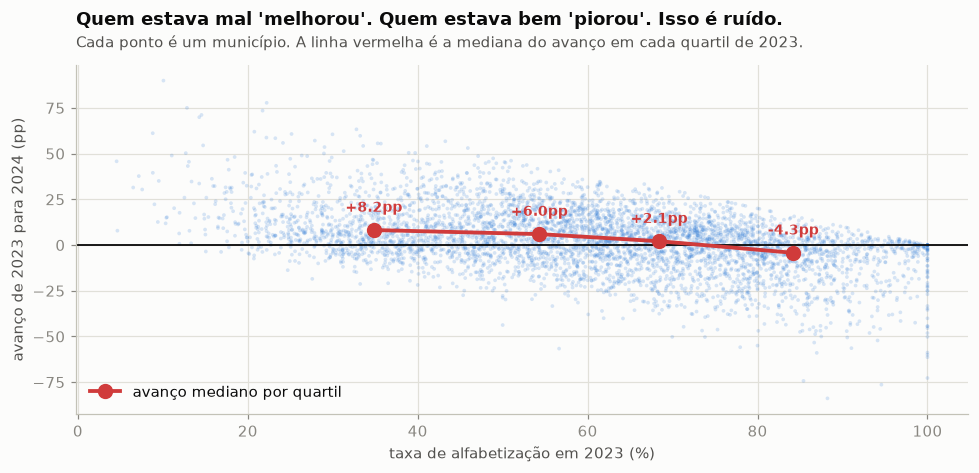

In [ ]:
fig, ax = plt.subplots()

ax.scatter(serie[2023], serie["avanco"], s=6, color=AZUL, alpha=0.18, edgecolors="none")
ax.axhline(0, color=TINTA, linewidth=1.2)

# a mediana do avanço em cada quartil de 2023
medianas = serie.groupby(quartil, observed=True).agg(
    taxa=(2023, "median"), avanco=("avanco", "median"))
ax.plot(medianas["taxa"], medianas["avanco"], color=VERMELHO, linewidth=2.5,
        marker="o", markersize=9, zorder=5, label="avanço mediano por quartil")

for rotulo, linha in medianas.iterrows():
    ax.annotate(f"{linha['avanco']:+.1f}pp", xy=(linha["taxa"], linha["avanco"]),
                xytext=(0, 12), textcoords="offset points", ha="center",
                fontsize=9, fontweight="bold", color=VERMELHO)

ax.set_xlabel("taxa de alfabetização em 2023 (%)")
ax.set_ylabel("avanço de 2023 para 2024 (pp)")
ax.grid()
ax.legend(loc="lower left")
titulos(ax, "Quem estava mal 'melhorou'. Quem estava bem 'piorou'. Isso é ruído.",
        "Cada ponto é um município. A linha vermelha é a mediana do avanço em cada quartil de 2023.")
plt.tight_layout()
plt.show()

### Isso se chama regressão à média, e é uma das armadilhas mais clássicas da estatística.

> **Traduzindo: o que é regressão à média?**
> Lembra do funil (3.2)? Um município pequeno pode ter uma taxa muito baixa em 2023 só por azar — três crianças mal num ano ruim. No ano seguinte, o azar não se repete, e a taxa "sobe". Não houve melhora nenhuma: o número só voltou para onde ele sempre esteve.
> Como o azar de 2023 empurrou o município para o fundo do ranking, **os piores de 2023 são, em parte, os mais azarados de 2023** — e é matematicamente esperado que "melhorem". O mesmo vale, ao contrário, para os campeões.

A correlação de **−0,45** entre a taxa de 2023 e o avanço é a assinatura disso. O quartil pior "subiu" 8 pontos; o melhor "caiu" 4.

**Um ranking de "quem mais melhorou" seria, em boa parte, um ranking de quem teve mais azar no ano anterior.**

Por isso a Gold **não publica ranking de evolução**, e o dicionário de dados diz isso com todas as letras. Com duas ondas, tendência é hipótese — não é fato.

## 2.4 — O gap traduzido em crianças

O `gap` da `meta_vs_resultado` é em pontos percentuais — bom para comparar, ruim para dimensionar. A pergunta de quem planeja é outra: **quantas crianças precisariam cruzar o corte para o município bater a meta?** Dá para responder juntando o `gap` com o volume da `indicador_municipio`.

municípios que não atingiram a meta de 2024: 1,237
crianças que precisariam cruzar o corte para TODOS baterem a meta: 70,669


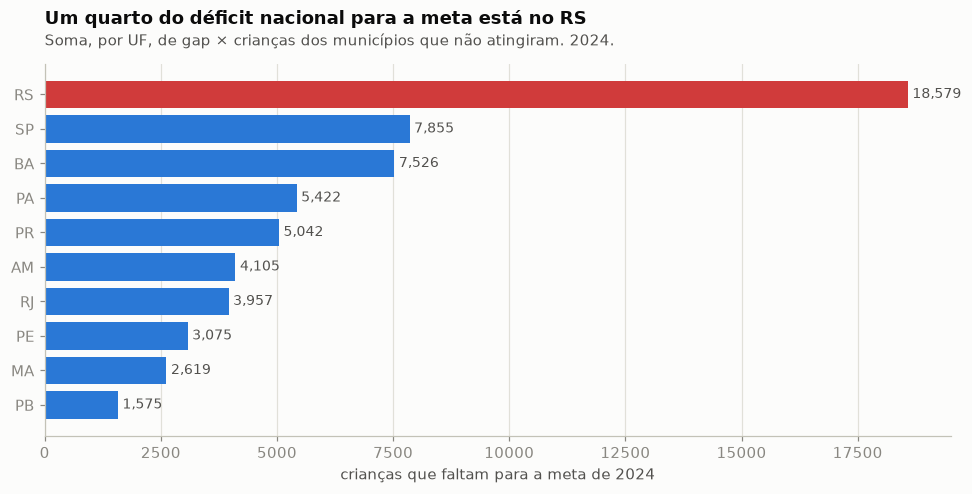

In [ ]:
nao = mm24[mm24["situacao_meta"] == "nao_atingiu"].merge(
    ind_mun.loc[ind_mun["ano"] == 2024,
                ["id_municipio", "taxa_alfabetizacao", "criancas_nao_alfabetizadas"]]
    .rename(columns={"taxa_alfabetizacao": "taxa_mun"}),
    on="id_municipio").dropna(subset=["criancas_nao_alfabetizadas"])

# o total de crianças do município, estimado do próprio déficit ponderado
nao["n_criancas"] = nao["criancas_nao_alfabetizadas"] * 100 / (100 - nao["taxa_mun"])
nao["criancas_para_meta"] = (-nao["gap"] / 100) * nao["n_criancas"]

print(f"municípios que não atingiram a meta de 2024: {len(nao):,}")
print(f"crianças que precisariam cruzar o corte para TODOS baterem a meta: "
      f"{nao['criancas_para_meta'].sum():,.0f}")

por_uf = nao.groupby("sigla_uf")["criancas_para_meta"].sum().sort_values().tail(10)

fig, ax = plt.subplots(figsize=(9, 4.6))
barras = ax.barh(por_uf.index,
                 por_uf.values,
                 color=[VERMELHO if s == "RS" else AZUL for s in por_uf.index])
ax.bar_label(barras, fmt="{:,.0f}", padding=3, fontsize=9, color=TINTA_2)
ax.set_xlabel("crianças que faltam para a meta de 2024")
ax.grid(axis="x")
titulos(ax, "Um quarto do déficit nacional para a meta está no RS",
        "Soma, por UF, de gap × crianças dos municípios que não atingiram. 2024.")
plt.tight_layout()
plt.show()

~71 mil crianças fecham a meta de 2024 do país inteiro — e **um quarto delas está no RS**, o rastro da seção 2.2 em números absolutos. É a mesma lição do laboratório (volume ≠ taxa), agora aplicada à meta: as UFs com os piores percentuais não são necessariamente as que mais precisam de crianças cruzando o corte.

## 2.5 — Vitórias suspeitas: a meta batida com a prova esvaziada

O laboratório mostrou que a falta não é aleatória: falta mais gente onde o desempenho é pior, e a taxa sai inflada. A Gold carrega essa suspeita como coluna — `alerta_participacao`, participação abaixo de 80%. O cruzamento que interessa: **alguém "atingiu" a meta com a prova esvaziada?**

In [ ]:
i24 = ind_mun[ind_mun["ano"] == 2024]
com_alerta = i24["alerta_participacao"].astype(bool)
print(f"municípios com alerta de participação (< 80%): "
      f"{int(com_alerta.sum())} de {len(i24):,}")
print(f"  taxa média COM alerta: {i24.loc[com_alerta, 'taxa_alfabetizacao'].mean():.1f}%")
print(f"  taxa média SEM alerta: {i24.loc[~com_alerta, 'taxa_alfabetizacao'].mean():.1f}%")
print()

suspeitas = (mm24[mm24["situacao_meta"] == "atingiu"]
             .merge(i24.loc[com_alerta, ["id_municipio", "taxa_participacao"]],
                    on="id_municipio"))
print(f"municípios que ATINGIRAM a meta com participação baixa: {len(suspeitas)}")
print()
print("os 5 casos com menor participação:")
suspeitas.nsmallest(5, "taxa_participacao")[
    ["sigla_uf", "id_municipio", "taxa_alfabetizacao", "gap",
     "taxa_participacao"]].round(1)

municípios com alerta de participação (< 80%): 395 de 5,519
  taxa média COM alerta: 51.7%
  taxa média SEM alerta: 64.0%

municípios que ATINGIRAM a meta com participação baixa: 32

os 5 casos com menor participação:


,sigla_uf,id_municipio,taxa_alfabetizacao,gap,taxa_participacao
23,SC,4207684,77.7,14.8,38.8
9,MG,3106606,85.0,22.2,55.6
10,MG,3117876,69.2,12.1,70.5
6,RN,2408953,31.6,10.1,71.0
29,SC,4218905,76.9,13.4,71.1


**32 municípios atingiram a meta com participação abaixo de 80%** — o caso extremo fez a prova com 38,8% das crianças: quase dois terços fora da conta. O padrão geral confirma o viés (taxa média de 51,7% com alerta contra 64,0% sem), então nesses 32 a leitura honesta é "meta atingida *entre os presentes*". É para isso que o alerta existe: não derruba o número, mas impede que ele seja lido sem contexto.

## 2.6 — Mesma taxa, mundos diferentes

Dois municípios com 50% de alfabetização são iguais? A taxa diz que sim. A `distribuicao_proficiencia` existe para dizer que não: ela mostra **onde** estão as crianças que não cruzaram o corte — logo abaixo dele, ou no fundo da escala (`pct_critico`, abaixo de 700 pontos).

municípios com taxa entre 48% e 52% (100+ alunos): 188
  % de crianças na faixa crítica entre eles: de 7% a 32%


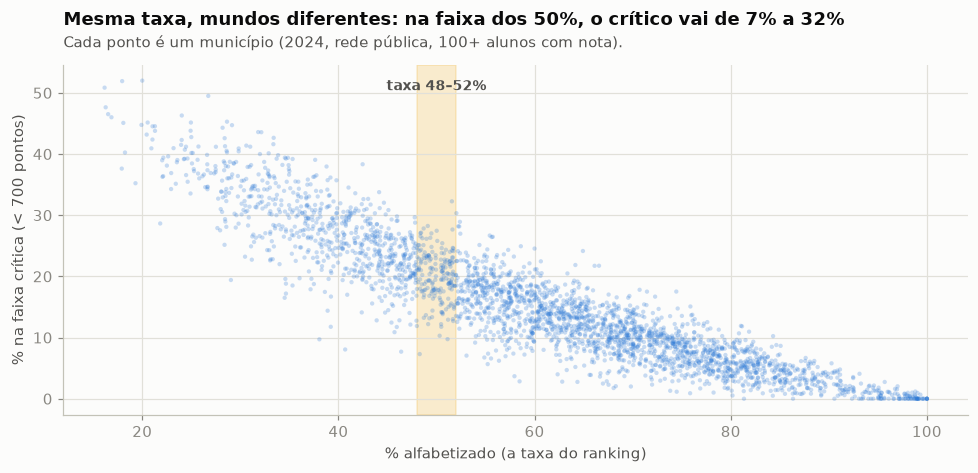

In [ ]:
dm = distrib[(distrib["nivel"] == "municipio") & (distrib["rede"] == "publica")
             & (distrib["ano"] == 2024) & (distrib["alunos_com_nota"] >= 100)]
faixa = dm[(dm["pct_alfabetizado"] >= 48) & (dm["pct_alfabetizado"] <= 52)]

print(f"municípios com taxa entre 48% e 52% (100+ alunos): {len(faixa)}")
print(f"  % de crianças na faixa crítica entre eles: "
      f"de {faixa['pct_critico'].min():.0f}% a {faixa['pct_critico'].max():.0f}%")

fig, ax = plt.subplots()
ax.scatter(dm["pct_alfabetizado"], dm["pct_critico"], s=8, color=AZUL,
           alpha=0.25, edgecolors="none")
ax.axvspan(48, 52, color=AMARELO, alpha=0.18, zorder=0)
ax.text(50, dm["pct_critico"].max() * 0.97, "taxa 48–52%",
        ha="center", color=TINTA_2, fontsize=9, fontweight="bold")

ax.set_xlabel("% alfabetizado (a taxa do ranking)")
ax.set_ylabel("% na faixa crítica (< 700 pontos)")
ax.grid()
titulos(ax, "Mesma taxa, mundos diferentes: na faixa dos 50%, o crítico vai de 7% a 32%",
        "Cada ponto é um município (2024, rede pública, 100+ alunos com nota).")
plt.tight_layout()
plt.show()

Nos 188 municípios com taxa entre 48% e 52%, o `pct_critico` varia de **7% a 32%** — mais de quatro vezes. No primeiro caso, o problema é empurrar quem está na porta do corte; no último, há uma população inteira no fundo da escala — e a mesma política não serve para os dois. **Um ranking por taxa trataria todos como o mesmo município.**

## 2.7 — Onde o esforço rende mais

A `pct_quase_la` mede o contingente a até 10 pontos do corte — as crianças "na porta". Se esse contingente fosse igual em todo lugar, seria só uma curiosidade. A pergunta: **ele é maior onde a situação é melhor, ou onde é pior?**

correlação entre pct_alfabetizado e pct_quase_la: -0.61


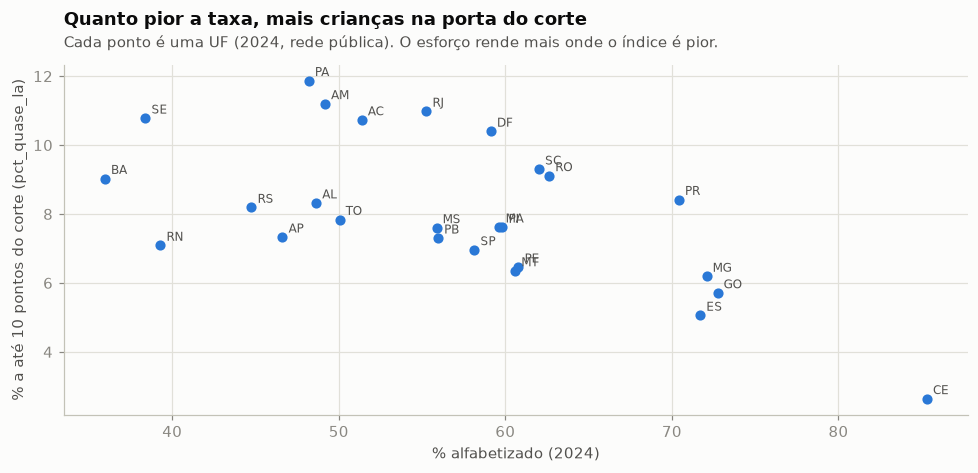

In [ ]:
duf = distrib[(distrib["nivel"] == "uf") & (distrib["rede"] == "publica")
              & (distrib["ano"] == 2024)]
print(f"correlação entre pct_alfabetizado e pct_quase_la: "
      f"{duf['pct_alfabetizado'].corr(duf['pct_quase_la']):+.2f}")

fig, ax = plt.subplots()
ax.scatter(duf["pct_alfabetizado"], duf["pct_quase_la"], s=32, color=AZUL)
for _, linha in duf.iterrows():
    ax.annotate(linha["sigla_uf"],
                (linha["pct_alfabetizado"], linha["pct_quase_la"]),
                xytext=(4, 3), textcoords="offset points",
                fontsize=8, color=TINTA_2)

ax.set_xlabel("% alfabetizado (2024)")
ax.set_ylabel("% a até 10 pontos do corte (pct_quase_la)")
ax.grid()
titulos(ax, "Quanto pior a taxa, mais crianças na porta do corte",
        "Cada ponto é uma UF (2024, rede pública). O esforço rende mais onde o índice é pior.")
plt.tight_layout()
plt.show()

A correlação é **−0,61**: quanto pior a taxa, *mais* crianças na porta do corte — PA e AM lideram, com ~12% dos alunos a dez pontos de cruzar. A conclusão é incômoda e útil ao mesmo tempo: o esforço rende mais exatamente onde o índice é pior. Não há trade-off entre "ajudar quem está pior" e "maximizar o resultado nacional" — aqui, as duas prioridades apontam para o mesmo lugar.

## 2.8 — A desigualdade que a taxa municipal esconde

O laboratório decompôs a variância e mostrou que 75% dela vive dentro da escola — mas aquilo era o grão aluno, da Silver. A `perfil_escola` permite a versão operacional da pergunta: **quanto as escolas de um mesmo município diferem entre si?**

municípios com 5+ escolas robustas (20+ alunos): 1,436
desvio-padrão mediano entre escolas do MESMO município: 13.2pp
  p10–p90: 7.8 a 19.7pp
correlação entre a taxa média e o desvio: -0.38


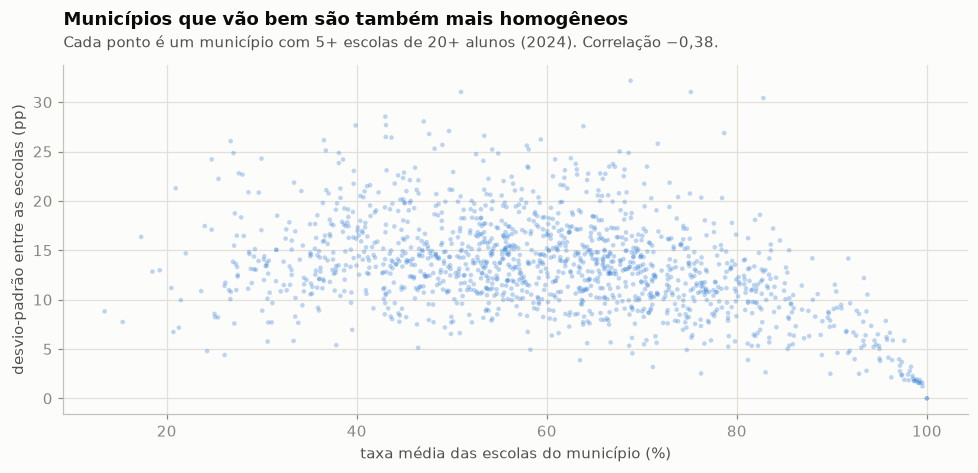

In [ ]:
p24 = perfil[(perfil["ano"] == 2024) & (perfil["alunos_com_nota"] >= 20)]
disp = (p24.groupby("id_municipio")
        .agg(escolas=("id_escola", "size"),
             taxa_media=("taxa_alfabetizacao", "mean"),
             desvio=("taxa_alfabetizacao", "std"))
        .query("escolas >= 5").dropna())

print(f"municípios com 5+ escolas robustas (20+ alunos): {len(disp):,}")
print(f"desvio-padrão mediano entre escolas do MESMO município: "
      f"{disp['desvio'].median():.1f}pp")
print(f"  p10–p90: {disp['desvio'].quantile(0.1):.1f} a {disp['desvio'].quantile(0.9):.1f}pp")
print(f"correlação entre a taxa média e o desvio: "
      f"{disp['taxa_media'].corr(disp['desvio']):+.2f}")

fig, ax = plt.subplots()
ax.scatter(disp["taxa_media"], disp["desvio"], s=9, color=AZUL,
           alpha=0.3, edgecolors="none")
ax.set_xlabel("taxa média das escolas do município (%)")
ax.set_ylabel("desvio-padrão entre as escolas (pp)")
ax.grid()
titulos(ax, "Municípios que vão bem são também mais homogêneos",
        "Cada ponto é um município com 5+ escolas de 20+ alunos (2024). Correlação −0,38.")
plt.tight_layout()
plt.show()

O desvio-padrão mediano é de **13,2pp entre escolas da mesma cidade** (p10–p90: 7,8 a 19,7). E a correlação de −0,38 entre a taxa média e o desvio diz algo maior: **municípios que vão bem são também mais homogêneos**. Melhorar a taxa e nivelar as escolas não parecem ser metas separadas — os municípios que conseguiram uma coisa tendem a ter conseguido a outra.

---

## Fechamento

A Parte 1 conferiu que a Gold tem a cara esperada — grão, colunas e o 59,2% oficial no lugar. A Parte 2 é a prova de uso: oito análises que dependem das colunas que o laboratório mandou criar (`ic95`, `situacao_meta`, `criancas_nao_alfabetizadas`, `pct_quase_la`, `residuo`).

| Seção | O achado |
|---|---|
| 2.1 | 49pp entre CE e BA; 6 UFs recuaram num ano em que o país subiu |
| 2.2 | RS: −18,7pp reais (~60× o ic95, participação estável) — a exceção que as colunas de incerteza confirmam |
| 2.3 | correlação −0,45 entre taxa de 2023 e avanço: ranking municipal de evolução seria ruído |
| 2.4 | ~71 mil crianças fecham a meta de 2024; um quarto delas no RS |
| 2.5 | 32 municípios "atingiram" a meta com participação abaixo de 80% |
| 2.6 | na faixa dos 50% de taxa, o `pct_critico` varia de 7% a 32% |
| 2.7 | correlação −0,61: quem está pior tem mais crianças na porta do corte |
| 2.8 | 13pp de desvio entre escolas da mesma cidade; quem vai bem é mais homogêneo |

Tudo aqui parte de `data/gold/` — nenhuma célula releu a Silver. É o teste que importa para uma camada analítica: **ela responde sozinha**. Cada coluna usada acima nasceu de uma decisão testada contra o gabarito em [`laboratorio_gold.ipynb`](laboratorio_gold.ipynb).